In [2]:
#ES-RNN

In [28]:
from ESRNN import ESRNN
from ESRNN.m4_data import *
from ESRNN.utils_evaluation import evaluate_prediction_owa
from ESRNN.utils_visualization import plot_grid_prediction

In [29]:
import numpy as np

# Define a temporary patch for np.asscalar
if not hasattr(np, "asscalar"):
    np.asscalar = lambda x: x.item()


In [52]:
X_train_df, y_train_df, X_test_df, y_test_df = prepare_m4_data( dataset_name="Hourly", 
   directory="/Users/cankocak/Desktop/Spring25/INDR491/m4 Dataset", 
   num_obs=414)


In [63]:

print(y_train_df.head(702))


    unique_id                  ds      y
0          H1 1970-01-01 00:00:00  605.0
1          H1 1970-01-01 01:00:00  586.0
2          H1 1970-01-01 02:00:00  586.0
3          H1 1970-01-01 03:00:00  559.0
4          H1 1970-01-01 04:00:00  511.0
..        ...                 ...    ...
697        H1 1970-01-30 01:00:00  752.0
698        H1 1970-01-30 02:00:00  739.0
699        H1 1970-01-30 03:00:00  684.0
700       H10 1970-01-01 00:00:00  513.0
701       H10 1970-01-01 01:00:00  512.0

[702 rows x 3 columns]


In [34]:

# Instantiate model
model = ESRNN(max_epochs=5, 
              # frequency of computing and reporting this loss
              freq_of_test=1, 
              batch_size=32, 
              
              # customize things around the learning rate
              learning_rate=0.02, per_series_lr_multip=0.5,
              lr_scheduler_step_size=7, lr_decay=0.5, 
              
              gradient_clipping_threshold=50, 
              rnn_weight_decay=0.0, noise_std=0.001, 
              level_variability_penalty=30, 
              
              # for probabilistic forecasting
              testing_percentile=50, training_percentile=50,
              
              ensemble=True, max_periods=371, 
              seasonality=[24, 168], input_size=24, output_size=48,
              cell_type='LSTM', state_hsize=40, 
              dilations=[[1, 4, 24, 168]], 
              add_nl_layer=False,
              random_seed=1, device='cpu')

In [35]:
# If y_test_df is provided the model will evaluate predictions on this set every freq_test epochs
model.fit(X_train_df, y_train_df)

Infered frequency: H
=============== Training ESRNN  ===============

========= Epoch 0 finished =========
Training time: 12.49797
Training loss (50 prc): 0.70241
========= Epoch 1 finished =========
Training time: 12.39315
Training loss (50 prc): 0.59291
========= Epoch 2 finished =========
Training time: 11.92806
Training loss (50 prc): 0.53480
========= Epoch 3 finished =========
Training time: 11.86602
Training loss (50 prc): 0.49684
========= Epoch 4 finished =========
Training time: 12.38184
Training loss (50 prc): 0.46950
Train finished! 



In [65]:
#Predict on test set
y_hat_df = model.predict(X_test_df)
print(y_hat_df)
# Evaluate predictions
final_owa, final_mase, final_smape = evaluate_prediction_owa(y_hat_df, y_train_df, 
                                                             X_test_df, y_test_df,
                                                             naive2_seasonality=24)

      unique_id                  ds      x         y_hat
0            H1 1970-01-30 04:00:00  Other    597.457153
1            H1 1970-01-30 05:00:00  Other    530.814514
2            H1 1970-01-30 06:00:00  Other    502.484436
3            H1 1970-01-30 07:00:00  Other    471.114258
4            H1 1970-01-30 08:00:00  Other    451.967102
...         ...                 ...    ...           ...
19867       H99 1970-01-31 23:00:00  Other  29857.484375
19868       H99 1970-02-01 00:00:00  Other  28069.011719
19869       H99 1970-02-01 01:00:00  Other  26835.621094
19870       H99 1970-02-01 02:00:00  Other  26828.599609
19871       H99 1970-02-01 03:00:00  Other  24395.521484

[19872 rows x 4 columns]
===============  Model evaluation  ==============
OWA: 0.987 
SMAPE: 15.624 
MASE: 2.69 


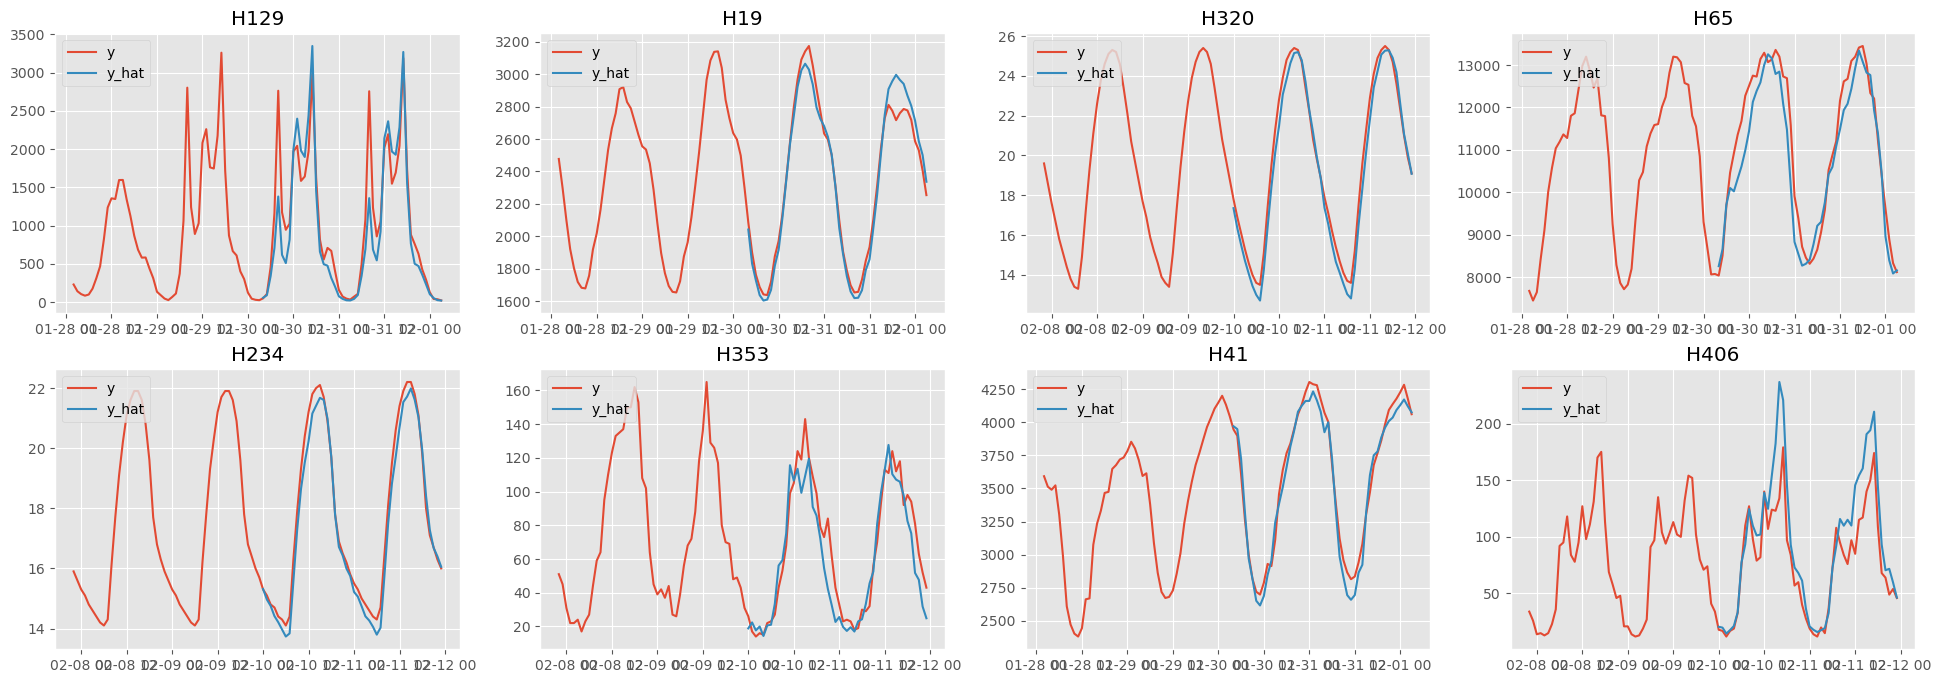

In [37]:
unique_ids = ['H129', 'H41', 'H406', 'H234', 
               'H65', 'H19', 'H320', 'H353']

plot_preds = pd.concat([y_train_df.groupby('unique_id').tail(50), 
                        y_test_df],  sort=True)

plot_grid_prediction(plot_preds, y_hat_df,  unique_ids=unique_ids)

In [48]:
file_path = "preprocessedBelgeler/ES_RNN adjusted.xlsx"  # Replace with actual file path
df = pd.read_excel(file_path)

# Convert Date format
df["ds"] = pd.to_datetime(df["ds"], format="%Y%m%d")

"""
df["x"] = df["x"].fillna("Unknown") 
print(X_train_df["x"].isna().sum()) 
"""

# Train-test split: 80% train, 20% test
train_size = int(0.8 * len(df))
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# Define Features (X) and Target (y)
X_columns = ["unique_id","ds", "x"]  # Features
y_column = [ "unique_id","ds","y"]  # Target variable

# Split into X and y for training and testing
X_train_df = train_df[X_columns]
y_train_df = train_df[y_column]

X_test_df = test_df[X_columns]
y_test_df = test_df[y_column]

X_test_df["unique_id"] = X_test_df["unique_id"].astype(str)
y_test_df["unique_id"] = y_test_df["unique_id"].astype(str)


/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_89745/2739393235.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_df["unique_id"] = X_test_df["unique_id"].astype(str)
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_89745/2739393235.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test_df["unique_id"] = y_test_df["unique_id"].astype(str)


In [49]:
print(X_test_df)
model.predict(X_test_df, y_test_df)

       unique_id         ds      x
93139        792 2023-02-01  Other
93140        792 2023-03-01  Other
93141        792 2023-05-01  Other
93142        792 2023-06-01  Other
93143        792 2023-07-01  Other
...          ...        ...    ...
116419      1208 2024-12-01  Other
116420      1208 2025-01-01  Other
116421      1208 2025-02-01  Other
116422      1208 2025-03-01  Other
116423      1208 2025-04-01  Other

[23285 rows x 3 columns]


,unique_id,ds,x,y_hat
0,792,2023-02-01,Other,NaN
1,792,2023-03-01,Other,NaN
2,792,2023-05-01,Other,NaN
3,792,2023-06-01,Other,NaN
4,792,2023-07-01,Other,NaN
...,...,...,...,...
23280,1208,2024-12-01,Other,NaN
23281,1208,2025-01-01,Other,NaN
23282,1208,2025-02-01,Other,NaN
23283,1208,2025-03-01,Other,NaN


In [11]:
#TCN

In [12]:
from darts import TimeSeries
from darts.dataprocessing.transformers import MissingValuesFiller


df = pd.read_csv("COMED_hourly.csv",parse_dates = True)
df = df.loc[df["Datetime"] > '2011-12-31'].reset_index(drop = True)
df.columns = ['timestamp', 'energy_mw']
df.head(5)

,timestamp,energy_mw
0,2011-12-31 01:00:00,9970.0
1,2011-12-31 02:00:00,9428.0
2,2011-12-31 03:00:00,9059.0
3,2011-12-31 04:00:00,8817.0
4,2011-12-31 05:00:00,8743.0


/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_68451/4199439176.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_day_avg = df.groupby(df['timestamp'].astype(str).str.split(" ").str[0]).mean().reset_index()


<Axes: xlabel='timestamp'>

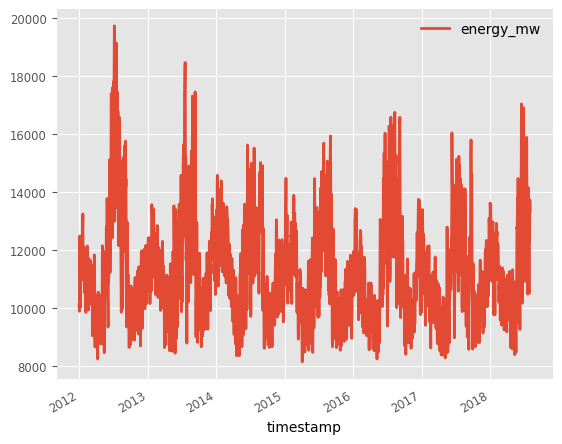

In [13]:
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df['timestamp'] = df.timestamp.dt.tz_localize(None)

df_day_avg = df.groupby(df['timestamp'].astype(str).str.split(" ").str[0]).mean().reset_index()
value_filler = MissingValuesFiller()
series = value_filler.transform(TimeSeries.from_dataframe(df_day_avg, 'timestamp', ['energy_mw']))
series.plot()

In [14]:
from darts.dataprocessing.transformers import Scaler
from darts.utils.timeseries_generation import datetime_attribute_timeseries

train, val = series.split_after(pd.Timestamp('20170901'))
scaler = Scaler()
train_transformed = scaler.fit_transform(train)
val_transformed = scaler.transform(val)
series_transformed = scaler.transform(series)

In [15]:
# add the day as a covariate
day_series = datetime_attribute_timeseries(
    series_transformed, attribute="day", one_hot=True
)
scaler_day = Scaler()
day_series = scaler_day.fit_transform(day_series)
train_day, val_day = day_series.split_after(pd.Timestamp("20170901"))

In [16]:

from darts.models import TCNModel

model = TCNModel(
    n_epochs = 2, 
    input_chunk_length = 365,
    output_chunk_length = 7,  # weekly forecast 
    dropout=0, 
    dilation_base=2, 
    weight_norm=True,
    kernel_size=7,
    num_filters=4,
    random_state=0
)

#solving float32 error
series_transformed = series_transformed.astype("float32")
day_series = day_series.astype("float32")


In [18]:
#model.fit(series=train_transformed, past_covariates=train_day, verbose=True)

In [35]:
from darts.metrics import rmse 

forecast_horizon = 7
last_obs = 400

            
backtest = model.historical_forecasts(
    series=series_transformed,
    past_covariates=day_series,
    start=0.7,
    forecast_horizon=7,
    stride= 7,
    retrain= True, verbose=False,
)

`enable_optimization=True` is ignored because `retrain` is not `False` or `0`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.
`enable_optimization=True` is ignored because `forecast_horizon > model.output_chunk_length`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 2.8 M  | train
-------------------------------------------------------------
2.8 M     Trainable params
6.3 K   

Training: |                                               | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | 

Training: |                                               | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [ ]:
series_transformed[-len(backtest) - last_obs:].plot()
backtest.plot(label='backtest (n=' + str(forecast_horizon) + ')')

print('Backtest RMSE = {}'.format(np.round( rmse(series_transformed, backtest),2 )))

In [ ]:
import torch

# Create a sample tensor on MPS
tensor = torch.randn(10, device="mps", dtype=torch.float32)

# Print its dtype
print(tensor.dtype)  # Should print torch.float32


In [ ]:
#N-Beats

In [20]:
from darts import concatenate
from darts.models import NBEATSModel
from darts.metrics import mape, rmse
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.utils.likelihood_models import QuantileRegression

In [21]:
EPOCHS = 5
INLEN = 32          # input size
BLOCKS = 64         
LWIDTH = 32
BATCH = 64          # batch size
LEARN = 1e-3        # learning rate
VALWAIT = 1         # epochs to wait before evaluating the loss on the test/validation set
N_FC = 1            # output size
RAND = 42           # random seed
N_JOBS = -1          # parallel processors to use;  -1 = all processors


SPLIT = 0.9         # train/test split


# parameters for the probabilistic forecast
N_SAMPLES = 100     # number of times a prediction is sampled from a probabilistic model
QUANTILES = [0.01, 0.1, 0.2, 0.5, 0.8, 0.9, 0.99]
qL1, qL2 = 0.01, 0.10                     # percentiles of predictions: lower bounds
qU1, qU2 = 1-qL1, 1-qL2,                  # upper bounds derived from lower bounds
label_q1 = f'{int(qU1 * 100)} / {int(qL1 * 100)} percentile band'
label_q2 = f'{int(qU2 * 100)} / {int(qL2 * 100)} percentile band'

In [ ]:

model = NBEATSModel(    input_chunk_length=INLEN,
                        output_chunk_length=N_FC, 
                        num_stacks=BLOCKS,
                        layer_widths=LWIDTH,
                        batch_size=BATCH,
                        n_epochs=EPOCHS,
                        nr_epochs_val_period=VALWAIT, 
                        likelihood=QuantileRegression(QUANTILES), 
                        optimizer_kwargs={"lr": LEARN}, 
                        model_name="NBEATS_EnergyES",
                        log_tensorboard=True,
                        generic_architecture=True, 
                        random_state=RAND,
                        force_reset=True,
                        save_checkpoints=True
                    
                    )

#solving float32 error
series_transformed = series_transformed.astype("float32")
day_series = day_series.astype("float32")




In [34]:
forecast_horizon = 7
last_obs = 400

            
backtest = model.historical_forecasts(
    series=series_transformed,
    past_covariates=day_series,
    start=0.7,
    forecast_horizon=7,
    stride= 7,
    retrain= True, verbose=False,
)

`enable_optimization=True` is ignored because `retrain` is not `False` or `0`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.
`enable_optimization=True` is ignored because `forecast_horizon > model.output_chunk_length`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 2.8 M  | train
-------------------------------------------------------------
2.8 M     Trainable params
6.3 K   

Training: |                                               | 0/? [00:00<?, ?it/s]

/Users/cankocak/anaconda3/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:384: `ModelCheckpoint(monitor='val_loss')` could not find the monitored key in the returned metrics: ['train_loss', 'epoch', 'step']. HINT: Did you call `log('val_loss', value)` in the `LightningModule`?
`Trainer.fit` stopped: `max_epochs=5` reached.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/cankocak/anaconda3/lib/python3.10/site-packages/darts/utils/likelihood_models.py:1273: UserWarning: MPS: no support for int64 repeats mask, casting it to int32. Support has been added in macOS 13.3 (Trigg

Training: |                                               | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 2.8 M  | train
-------------------------------------------------------------
2.8 M     Trainable params
6.3 K     Non-trainable params
2.8 M     Total params
11.168    Total estimated model params size (MB)
838       Modules in train mode
0         Modules in eval mode
/Users/cankoc

...

Training: |                                               | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 2.8 M  | train
-------------------------------------------------------------
2.8 M     Trainable params
6.3 K     Non-trainable params
2.8 M     Total params
11.168    Total estimated model params size (MB)
838       Modules in train mode
0         Modules in eval mode
/Users/cankoc

Training: |                                               | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [42]:
pip install lazypredict


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 2.5 MB/s eta 0:00:0000:0100:010m
Note: you may need to restart the kernel to use updated packages.


In [43]:
import lazypredict


In [ ]:
from lazypredict.Supervised import LazyRegressor
from sklearn import datasets
from sklearn.utils import shuffle
import numpy as np

boston = datasets.load_boston()
X, y = shuffle(boston.data, boston.target, random_state=13)
X = X.astype(np.float32)

offset = int(X.shape[0] * 0.9)

X_train, y_train = X[:offset], y[:offset]
X_test, y_test = X[offset:], y[offset:]

reg = LazyRegressor(verbose=0, ignore_warnings=False, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

print(models)
